## Contents

1. [Capon/MVDR Fundamentals](#capon-mvdr-fundamentals)
2. [Capon/MVDR Performance](#capon-mvdr-performance)
   1. [Forward–Backward Averaging and Diagonal Loading](#forward-backward-averaging-and-diagonal-loading)
   2. [Angular Resolution](#angular-resolution)
   3. [DoA Estimation Accuracy](#doa-estimation-accuracy)
   4. [Model Mismatch](#model-mismatch)

<a id="capon-mvdr-fundamentals"></a>

## Capon/MVDR Fundamentals

The Capon, or Minimum Variance Distortionless Response (MVDR), beamformer is an adaptive spatial filtering method. Its weights depend on the estimated covariance matrix and therefore adapt to the measured spatial environment.

The angular scan can be interpreted as a bank of spatial FIR filters. The same array snapshot $\mathbf{x}[k]$ is applied to every branch, while the $i$-th branch uses weights $\mathbf{w}(\theta_i)$ corresponding to the steering direction $\theta_i$.

<p align="center">
  <img
    src="../docs/images/capon_mvdr_steering_grid.png"
    alt="Capon MVDR beamformer on a steering-angle grid"
    width="60%">
</p>


The output of the $i$-th spatial filter is

$$
y(\theta_i,k)
=
\mathbf{w}^{H}(\theta_i)\mathbf{x}[k].
$$

The spatial spectrum is obtained from the average output power of each filter:

$$
P(\theta_i)
=
\mathbb{E}\!\left[
\left|y(\theta_i,k)\right|^2
\right].
$$

Substituting the filter output gives

$$
P(\theta_i)
=
\mathbb{E}\!\left[
\mathbf{w}^{H}(\theta_i)
\mathbf{x}[k]\mathbf{x}^{H}[k]
\mathbf{w}(\theta_i)
\right].
$$

Using the covariance matrix

$$
\mathbf{R}
=
\mathbb{E}\!\left[
\mathbf{x}[k]\mathbf{x}^{H}[k]
\right],
$$

the filter output power becomes

$$
P(\theta_i)
=
\mathbf{w}^{H}(\theta_i)
\mathbf{R}
\mathbf{w}(\theta_i).
$$

For each steering direction, MVDR selects the weights that minimize this output power while preserving unity gain toward the tested direction:

$$
\min_{\mathbf{w}}
\mathbf{w}^{H}\mathbf{R}\mathbf{w},
\qquad
\text{subject to}
\qquad
\mathbf{w}^{H}\mathbf{a}(\theta_i)=1.
$$

The resulting adaptive weights are

$$
\mathbf{w}_{\mathrm{MVDR}}(\theta_i)
=
\frac{
\mathbf{R}^{-1}\mathbf{a}(\theta_i)
}{
\mathbf{a}^{H}(\theta_i)
\mathbf{R}^{-1}
\mathbf{a}(\theta_i)
}.
$$

Substituting these weights into the output-power expression gives the Capon spatial spectrum:

$$
P_{\mathrm{Capon}}(\theta_i)
=
\frac{1}{
\mathbf{a}^{H}(\theta_i)
\mathbf{R}^{-1}
\mathbf{a}(\theta_i)
}.
$$

In practice, $\mathbf{R}$ is replaced by the sample covariance matrix $\hat{\mathbf{R}}$. Peaks in the Capon spectrum indicate directions for which the distortionless constraint can be maintained while minimizing the remaining spatial power.


<a id="capon-mvdr-performance"></a>

## Capon/MVDR Performance

The practical performance of the Capon/MVDR estimator depends not only on the array aperture, but also on the quality of the covariance-matrix estimate, the available SNR and snapshot support, and the accuracy of the assumed array model.

This section examines four aspects that are particularly important in practical DoA estimation:

1. [Forward–Backward Averaging and Diagonal Loading](#forward-backward-averaging-and-diagonal-loading)
2. [Angular Resolution](#angular-resolution)
3. [DoA Estimation Accuracy](#doa-estimation-accuracy)
4. [Model Mismatch](#model-mismatch)

**Forward–Backward Averaging** and **Diagonal Loading** are covariance-matrix preprocessing techniques that can improve the robustness of the Capon estimator. Forward–backward averaging exploits the symmetry of a uniform linear array by combining the sample covariance matrix with its conjugated and reversed counterpart, while diagonal loading regularizes the covariance matrix by adding a scaled identity matrix.

The following subsections then examine how Capon performance changes with target separation, SNR, snapshot support, and steering-vector mismatch.

Detailed information about covariance estimation and preprocessing is provided in the [Covariance Matrix](https://farbius.github.io/fmcw-radar-doa/02_covariance_matrix.html) chapter.

<a id="forward-backward-averaging-and-diagonal-loading"></a>

### Forward–Backward Averaging and Diagonal Loading

#### Forward–Backward Averaging

The figure compares Capon/MVDR spectra obtained with and without forward–backward averaging of the covariance matrix. The measurement contains two corner reflectors in an off-boresight configuration with an angular separation of approximately $23^\circ$ and a lateral separation of about $2.7$ m.

<p align="center">
  <img
    src="../docs/images/capon_FB_analysis.png"
    alt="Forward-backward averaging analysis"
    width="90%">
</p>

Forward–backward averaging produces several visible effects:

- the main peaks become narrower;
- the spectral floor and secondary structures are suppressed by several dB;
- the valley between the two target peaks becomes deeper;
- the estimated target directions change only slightly.

Overall, forward–backward averaging exploits the symmetry of a uniform linear array to improve the covariance-matrix estimate. For Capon processing, this typically produces cleaner and sharper spatial peaks, suppresses spurious structure, and improves the separation of closely spaced targets.

#### Diagonal Loading

The same off-boresight target scenario is used for the diagonal-loading analysis. Forward–backward averaging is enabled, while the diagonal-loading factor is varied from $10^{0}$ to $10^{-7}$ in decade steps.

<p align="center">
  <img
    src="../docs/images/capon_DL_analysis.png"
    alt="Diagonal-loading analysis"
    width="90%">
</p>

Diagonal loading regularizes the covariance matrix used by the Capon beamformer. Large loading improves robustness but reduces adaptivity and broadens the spatial response. As the loading decreases, Capon increasingly exploits the measured covariance structure, producing narrower peaks and stronger target separation.

In this measurement, the spectrum changes only slightly below approximately $10^{-3}$, indicating that further reduction of the loading factor provides little additional improvement in angular resolution.

<a id="angular-resolution"></a>

### Angular Resolution

The angular resolution of the Capon/MVDR beamformer depends on both the physical array aperture and the quality of the covariance-matrix estimate. A larger aperture provides greater spatial discrimination, while sufficient **SNR** and **snapshot support** allow the adaptive beamformer to form narrow spatial responses and suppress energy from neighboring directions.

Therefore, Capon can resolve targets separated by less than the conventional beamwidth, but this super-resolution capability degrades at low SNR or when too few snapshots are available for reliable covariance estimation.

The following simulation considers an eight-element $\lambda/2$ ULA and two closely spaced targets. Capon spectra are compared for high SNR, low SNR, and reduced snapshot support.

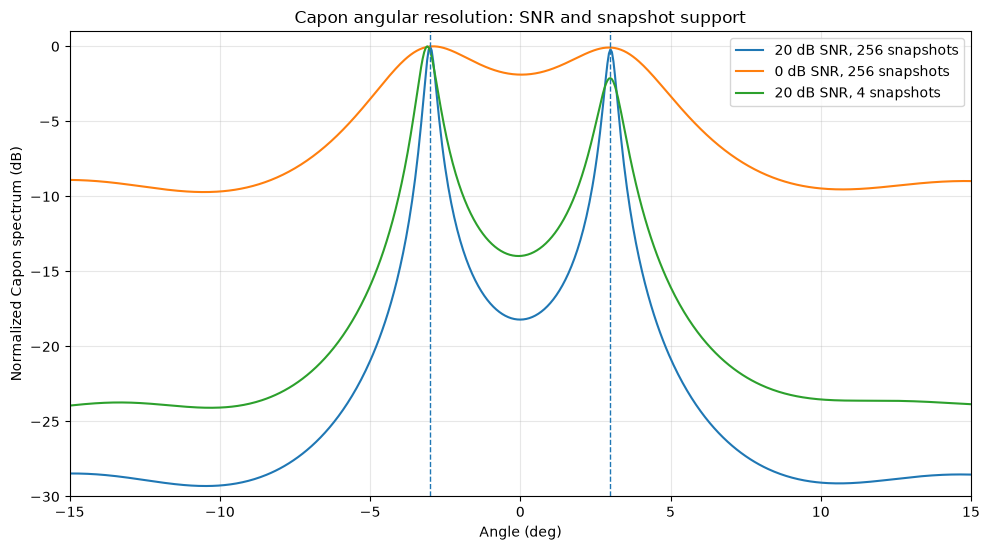

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Capon angular-resolution example
# ------------------------------------------------------------
M = 16
target_angles = [-3.0, 3.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)

def steering(theta):
    return np.exp(1j * np.pi * m * np.sin(np.deg2rad(theta)))

def capon_spectrum(snr_db, n_snapshots, seed=1):
    rng = np.random.default_rng(seed)

    A = np.column_stack([steering(t) for t in target_angles])
    S = (rng.standard_normal((2, n_snapshots))
         + 1j * rng.standard_normal((2, n_snapshots))) / np.sqrt(2)

    Xs = A @ S
    noise_power = np.mean(np.abs(Xs)**2) / 10**(snr_db / 10)
    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape) + 1j * rng.standard_normal(Xs.shape)
    )

    R = X @ X.conj().T / n_snapshots
    R += 1e-4 * np.trace(R).real / M * np.eye(M)
    R_inv = np.linalg.inv(R)

    P = np.array([
        1.0 / np.real(steering(t).conj() @ R_inv @ steering(t))
        for t in angle_grid
    ])

    return 10 * np.log10(P / P.max())

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 5.6))

plt.plot(angle_grid, capon_spectrum(20, 256),
         label="20 dB SNR, 256 snapshots")
plt.plot(angle_grid, capon_spectrum(0, 256),
         label="0 dB SNR, 256 snapshots")
plt.plot(angle_grid, capon_spectrum(20, 4),
         label="20 dB SNR, 4 snapshots")

for theta in target_angles:
    plt.axvline(theta, linestyle="--", linewidth=1)

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Capon spectrum (dB)")
plt.title("Capon angular resolution: SNR and snapshot support")
plt.xlim(-15, 15)
plt.ylim(-30, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The high-SNR case with sufficient snapshot support produces two distinct Capon peaks close to the true target directions. This demonstrates the ability of the adaptive beamformer to resolve targets separated by less than the conventional beamwidth of the eight-element array.

Reducing the SNR weakens the spatial information contained in the covariance matrix, causing the two responses to broaden and eventually merge. Reducing the number of snapshots makes the covariance estimate less reliable, which can distort the peak shapes and amplitudes even when the SNR remains high.

Thus, Capon angular resolution is not determined by array aperture alone. Its practical resolution depends strongly on **SNR, snapshot support, and covariance-matrix quality**.

The angular-resolution behavior of the Capon/MVDR estimator can be quantified using the **probability of resolution** rather than only inspecting individual spectra.

The following Monte Carlo simulation considers a 16-element $\lambda/2$ ULA with two uncorrelated sources separated by $6^\circ$. Two target geometries are compared:

* a broadside pair at $-1.5^\circ$ and $+1.5^\circ$;
* an off-boresight pair at $43.5^\circ$ and $46.5^\circ$, centered at $45^\circ$.

For each SNR value, multiple independent noise realizations are generated. A trial is counted as resolved when the Capon spectrum contains two distinct peaks and each estimated direction lies within half of the target separation from the corresponding true direction.

The resulting probability of resolution is
$$
P_{\mathrm{res}}
=

\frac{N_{\mathrm{resolved}}}{N_{\mathrm{trials}}}.
$$

This provides a numerical measure of how reliably Capon separates two closely spaced sources as a function of SNR and steering direction.


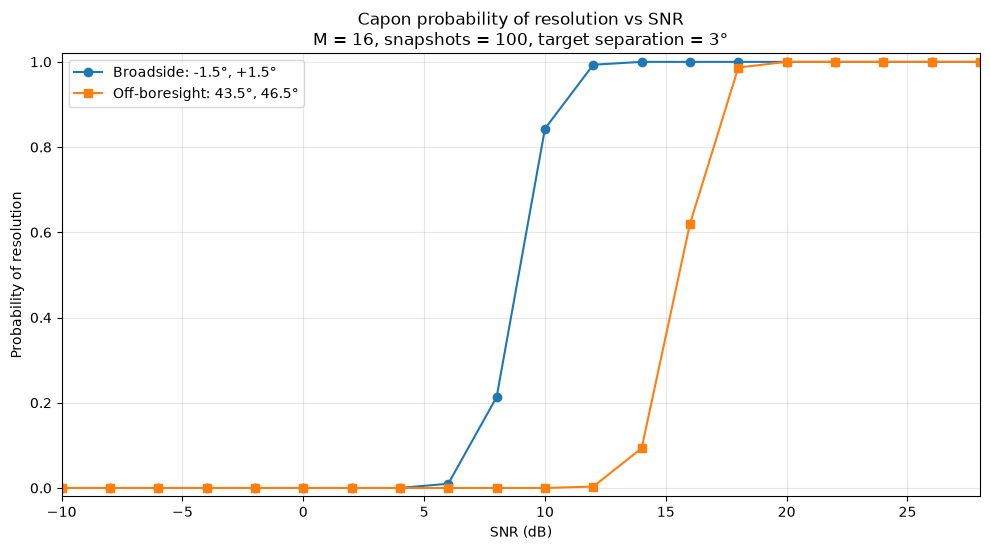

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Capon probability-of-resolution example
# ------------------------------------------------------------

M = 16
n_snapshots = 100
n_trials = 300

snr_db_values = np.arange(-10, 30, 2)

# Same physical angular separation in both scenarios
delta_theta = 3.0

target_angles_broadside = np.array([
    -delta_theta / 2,
    +delta_theta / 2
])

target_angles_off_boresight = np.array([
    45.0 - delta_theta / 2,
    45.0 + delta_theta / 2
])

m = np.arange(M)

# Fine spectral grid
angle_grid = np.linspace(-20, 70, 1801)

# Diagonal loading
dl_factor = 1e-4


# ------------------------------------------------------------
# Steering vector
# ------------------------------------------------------------

def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )


# Precompute steering matrix for the complete scan grid
A_grid = np.column_stack([
    steering(theta) for theta in angle_grid
])


# ------------------------------------------------------------
# Capon spectrum
# ------------------------------------------------------------

def capon_spectrum(
    target_angles,
    snr_db,
    n_snapshots,
    rng
):
    # Source steering matrix
    A = np.column_stack([
        steering(theta)
        for theta in target_angles
    ])

    # Two independent complex Gaussian source signals
    S = (
        rng.standard_normal((2, n_snapshots))
        + 1j * rng.standard_normal((2, n_snapshots))
    ) / np.sqrt(2)

    # Noise-free received snapshots
    Xs = A @ S

    # Noise power for requested array SNR
    signal_power = np.mean(np.abs(Xs)**2)

    noise_power = (
        signal_power
        / 10**(snr_db / 10)
    )

    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    X = Xs + noise

    # Sample covariance matrix
    R = X @ X.conj().T / n_snapshots

    # Diagonal loading
    R += (
        dl_factor
        * np.trace(R).real / M
        * np.eye(M)
    )

    R_inv = np.linalg.inv(R)

    # Capon denominator for all scan directions
    denominator = np.real(
        np.sum(
            A_grid.conj()
            * (R_inv @ A_grid),
            axis=0
        )
    )

    P = 1.0 / denominator

    return P


# ------------------------------------------------------------
# Local-maximum detection
# ------------------------------------------------------------

def find_local_peaks(P):
    """
    Return indices of all strict local maxima.
    """

    return np.where(
        (P[1:-1] > P[:-2])
        & (P[1:-1] > P[2:])
    )[0] + 1


# ------------------------------------------------------------
# Resolution criterion
# ------------------------------------------------------------

def is_resolved(P, target_angles):
    """
    Van-Trees-like resolution criterion:

    1. Two distinct spectral peaks must exist.
    2. One peak must correspond to each target.
    3. Each peak must be within delta_theta / 2
       of its true target direction.
    """

    peak_indices = find_local_peaks(P)

    if len(peak_indices) < 2:
        return False

    peak_angles = angle_grid[peak_indices]
    peak_values = P[peak_indices]

    # Restrict attention to the angular interval around the
    # two targets. This prevents distant sidelobes/noise peaks
    # from being interpreted as target peaks.
    margin = delta_theta / 2

    search_min = target_angles[0] - margin
    search_max = target_angles[1] + margin

    valid = (
        (peak_angles >= search_min)
        & (peak_angles <= search_max)
    )

    peak_angles = peak_angles[valid]
    peak_values = peak_values[valid]

    if len(peak_angles) < 2:
        return False

    # Sort candidate peaks by spectral power
    order = np.argsort(peak_values)[::-1]

    peak_angles = peak_angles[order]

    # Take the two strongest candidate peaks
    estimated_angles = np.sort(
        peak_angles[:2]
    )

    true_angles = np.sort(target_angles)

    # Van-Trees-like tolerance:
    # estimate must be within half the target separation
    tolerance = delta_theta / 2

    return np.all(
        np.abs(
            estimated_angles - true_angles
        ) <= tolerance
    )


# ------------------------------------------------------------
# Monte Carlo probability of resolution
# ------------------------------------------------------------

def probability_of_resolution(
    target_angles,
    snr_db_values,
    n_trials,
    seed
):
    rng = np.random.default_rng(seed)

    probabilities = []

    for snr_db in snr_db_values:

        resolved_count = 0

        for _ in range(n_trials):

            P = capon_spectrum(
                target_angles,
                snr_db,
                n_snapshots,
                rng
            )

            if is_resolved(
                P,
                target_angles
            ):
                resolved_count += 1

        probability = (
            resolved_count / n_trials
        )

        probabilities.append(probability)

    return np.array(probabilities)


# ------------------------------------------------------------
# Run simulations
# ------------------------------------------------------------

p_res_broadside = probability_of_resolution(
    target_angles_broadside,
    snr_db_values,
    n_trials,
    seed=1
)

p_res_off_boresight = probability_of_resolution(
    target_angles_off_boresight,
    snr_db_values,
    n_trials,
    seed=2
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.plot(
    snr_db_values,
    p_res_broadside,
    marker="o",
    label="Broadside: -1.5°, +1.5°"
)

plt.plot(
    snr_db_values,
    p_res_off_boresight,
    marker="s",
    label="Off-boresight: 43.5°, 46.5°"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Probability of resolution")

plt.title(
    "Capon probability of resolution vs SNR\n"
    f"M = {M}, snapshots = {n_snapshots}, "
    f"target separation = {delta_theta:.0f}°"
)

plt.xlim(
    snr_db_values[0],
    snr_db_values[-1]
)

plt.ylim(-0.02, 1.02)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The probability of resolution increases with SNR because the sample covariance matrix becomes less affected by noise and the two Capon peaks become more stable.

For the same physical angular separation, the off-boresight pair is expected to require a higher SNR for reliable resolution than the broadside pair. For a $\lambda/2$ ULA, spatial frequency is

$$
\mu=\pi\sin\theta,
$$

and therefore a small angular separation corresponds approximately to

$$
\Delta\mu
\approx
\pi\cos\theta,\Delta\theta.
$$

Since $\cos\theta$ decreases away from broadside, the same angular separation produces a smaller separation in spatial frequency at large steering angles. The corresponding steering vectors become more similar, making the two sources harder to distinguish.

Thus, Capon resolution depends not only on SNR and snapshot support, but also on the target steering direction:

$$
P_{\mathrm{res}}
=

f!\left(
\mathrm{SNR},
K,
\Delta\theta,
\theta_{\mathrm{center}}
\right).
$$

The simulation therefore illustrates the practical degradation of angular resolution away from broadside.


<a id="doa-estimation-accuracy"></a>

### DoA Estimation Accuracy

The accuracy of the Capon/MVDR estimator depends on the quality of the sample covariance matrix,

$$
\hat{\mathbf R}
=

\frac{1}{K}
\sum_{k=1}^{K}
\mathbf x_k\mathbf x_k^H,
$$

where $K$ is the number of snapshots.

The following Monte Carlo simulation evaluates the DoA **RMSE** for two sources separated by $6^\circ$ while increasing the number of snapshots. Two SNR levels are considered to illustrate the combined effect of noise and covariance-estimation support.

For each value of $K$, the Capon spectrum is estimated repeatedly using independent signal and noise realizations, and the RMSE of the detected DoAs is calculated relative to the known source directions.


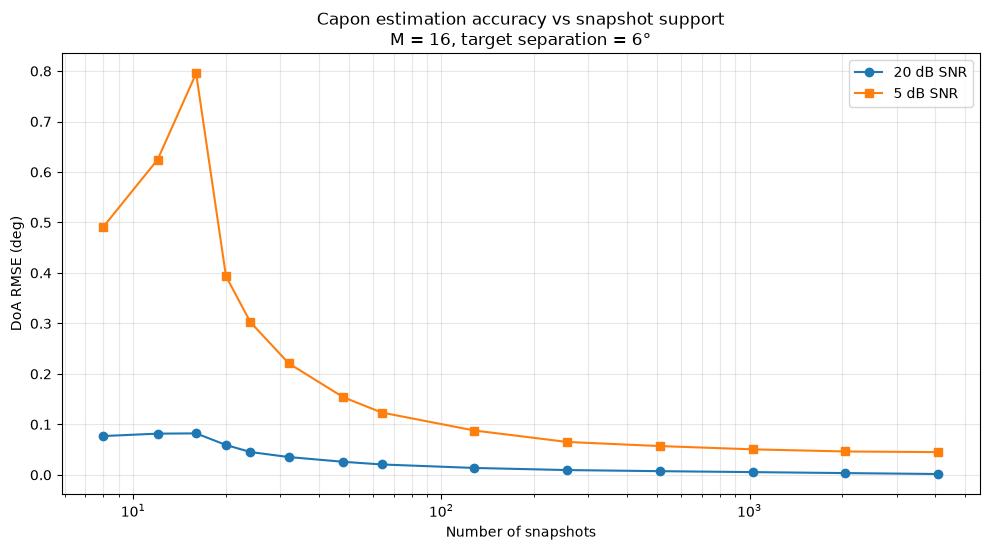

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Capon RMSE versus number of snapshots
# ------------------------------------------------------------

M = 16
n_trials = 300
snapshot_values = np.array([8, 12, 16, 20, 24, 32, 48, 64, 128, 256, 512, 1024, 2048, 4096])

snr_values = [20, 5]

delta_theta = 6.0
target_angles = np.array([-delta_theta / 2, +delta_theta / 2])

m = np.arange(M)
angle_grid = np.linspace(-10, 10, 1601)
dl_factor = 1e-4


def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )


A_grid = np.column_stack([
    steering(theta) for theta in angle_grid
])


def estimate_doa(n_snapshots, snr_db, rng):
    A = np.column_stack([
        steering(theta) for theta in target_angles
    ])

    S = (
        rng.standard_normal((2, n_snapshots))
        + 1j * rng.standard_normal((2, n_snapshots))
    ) / np.sqrt(2)

    Xs = A @ S

    noise_power = (
        np.mean(np.abs(Xs)**2)
        / 10**(snr_db / 10)
    )

    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    R = X @ X.conj().T / n_snapshots
    R += (
        dl_factor
        * np.trace(R).real / M
        * np.eye(M)
    )

    R_inv = np.linalg.inv(R)

    P = 1.0 / np.real(
        np.sum(
            A_grid.conj() * (R_inv @ A_grid),
            axis=0
        )
    )

    peaks = np.where(
        (P[1:-1] > P[:-2])
        & (P[1:-1] > P[2:])
    )[0] + 1

    if len(peaks) < 2:
        return None

    strongest = peaks[np.argsort(P[peaks])[-2:]]
    return np.sort(angle_grid[strongest])


def rmse_vs_snapshots(snr_db, seed):
    rng = np.random.default_rng(seed)
    rmse = []

    for K in snapshot_values:
        errors = []

        for _ in range(n_trials):
            est = estimate_doa(K, snr_db, rng)

            if est is not None:
                errors.extend(est - target_angles)

        rmse.append(
            np.sqrt(np.mean(np.square(errors)))
            if errors else np.nan
        )

    return np.array(rmse)


rmse_20 = rmse_vs_snapshots(snr_values[0], seed=1)
rmse_10 = rmse_vs_snapshots(snr_values[1], seed=2)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.semilogx(
    snapshot_values,
    rmse_20,
    "o-",
    label=f"{snr_values[0]} dB SNR"
)

plt.semilogx(
    snapshot_values,
    rmse_10,
    "s-",
    label=f"{snr_values[1]} dB SNR"
)

plt.xlabel("Number of snapshots")
plt.ylabel("DoA RMSE (deg)")
plt.title(
    "Capon estimation accuracy vs snapshot support\n"
    f"M = {M}, target separation = {delta_theta:.0f}°"
)

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Increasing the number of snapshots generally reduces the DoA estimation error because the sample covariance matrix becomes a more accurate estimate of the underlying covariance.

At high SNR, the Capon estimator achieves low RMSE even with relatively limited snapshot support, and the error decreases further as $K$ increases. At lower SNR, substantially more snapshots are required before the estimate becomes stable.

The non-monotonic behavior at very small $K$ is caused by the high variability of the poorly estimated covariance matrix and occasional inaccurate peak localization. Once sufficient snapshot support is available, the expected trend becomes clear:

$$
K \uparrow
\quad\Rightarrow\quad
\hat{\mathbf R}\rightarrow\mathbf R
\quad\Rightarrow\quad
\mathrm{RMSE}\downarrow.
$$

Thus, Capon performance is determined jointly by **SNR and snapshot support**: high SNR cannot completely compensate for an unreliable covariance estimate, while additional snapshots improve estimation stability, particularly under noisy conditions.


<a id="model-mismatch"></a>

### Model Mismatch

Capon/MVDR assumes that the steering vector used by the beamformer accurately represents the true array response. In practice, residual channel phase errors, gain mismatch, antenna-position errors, or imperfect calibration can introduce a mismatch between the measured data and the assumed array model.

The following simulation introduces controlled channel-phase errors into the received signals while Capon processing still uses the ideal steering vectors. This illustrates how increasing model mismatch can bias the estimated directions, distort the spatial spectrum, and reduce target separability.

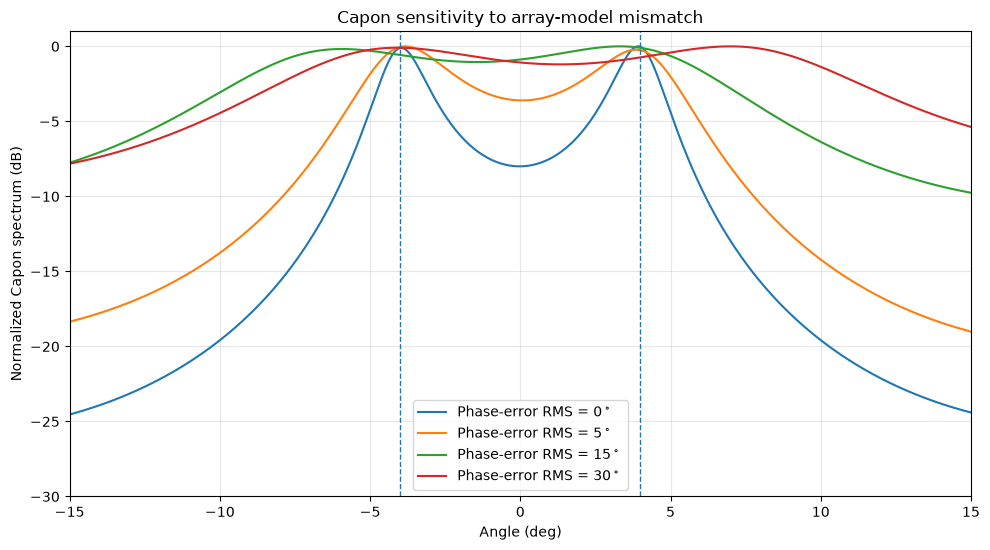

In [2]:
import numpy as np
import matplotlib.pyplot as plt

M = 8
target_angles = [-4.0, 4.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)
rng = np.random.default_rng(4)

def steering(theta):
    return np.exp(1j * np.pi * m * np.sin(np.deg2rad(theta)))

def capon_with_mismatch(phase_rms_deg):
    L, snr_db = 256, 20

    phase_err = np.deg2rad(
        rng.normal(0.0, phase_rms_deg, M)
    )
    D = np.diag(np.exp(1j * phase_err))

    A_true = np.column_stack(
        [D @ steering(t) for t in target_angles]
    )

    S = (rng.standard_normal((2, L))
         + 1j * rng.standard_normal((2, L))) / np.sqrt(2)

    Xs = A_true @ S
    noise_power = np.mean(np.abs(Xs)**2) / 10**(snr_db / 10)

    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    R = X @ X.conj().T / L
    R += 1e-3 * np.trace(R).real / M * np.eye(M)
    R_inv = np.linalg.inv(R)

    P = np.array([
        1.0 / np.real(
            steering(t).conj() @ R_inv @ steering(t)
        )
        for t in angle_grid
    ])

    return 10 * np.log10(P / P.max())

plt.figure(figsize=(10, 5.6))

for phase_rms in [0, 5, 15, 30]:
    plt.plot(
        angle_grid,
        capon_with_mismatch(phase_rms),
        label=rf"Phase-error RMS = {phase_rms}$^\circ$"
    )

for theta in target_angles:
    plt.axvline(theta, linestyle="--", linewidth=1)

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized Capon spectrum (dB)")
plt.title("Capon sensitivity to array-model mismatch")
plt.xlim(-15, 15)
plt.ylim(-30, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The simulation shows that Capon/MVDR is highly sensitive to array-model mismatch. With an ideal steering model, the two closely spaced targets are clearly resolved and their peaks appear near the true directions.

As channel-phase mismatch increases, the Capon spectrum becomes progressively distorted: the peaks broaden, their amplitudes become asymmetric, and the estimated directions can shift away from the true target angles. For sufficiently large mismatch, the two-target structure may no longer be reliably resolved.

Thus, the super-resolution capability of Capon depends not only on SNR and snapshot support, but also on accurate array calibration and steering-vector modeling.